## IMPORTING LIBRARIES

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn import metrics


## Data Collection and Analysis

In [145]:
# loading the data from csv file to a pandas dataframe
insurance_dataset = pd.read_csv("insurance.csv")


In [146]:
# first 5 rows of the dataframe
insurance_dataset.head() 

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [147]:
# number of rows and columns 
insurance_dataset.shape

(1338, 7)

In [148]:
 # getting some information about the dataset 
insurance_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


 # Categorical Features 
 - Sex
 - Smoker
 - Region

In [149]:
# checking for missing values 
insurance_dataset.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Data Analysis

In [150]:
#Statistical Measure of the dataset
insurance_dataset .describe() 

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


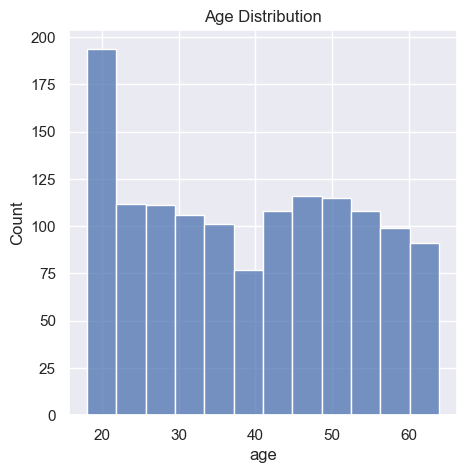

In [151]:
#Distribution of age value 
sns.set()
plt.figure(figsize=(5,5))
sns.histplot(insurance_dataset['age'])
plt.title('Age Distribution')
plt.show()

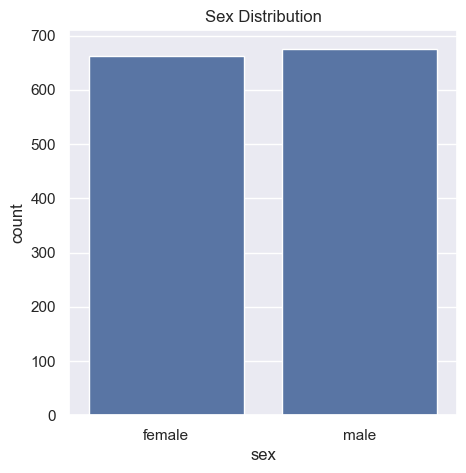

In [152]:
# Gender Column 
plt.figure(figsize=(5,5)) 
sns.countplot(x='sex',data = insurance_dataset) 
plt.title('Sex Distribution')
plt.show()


In [153]:
insurance_dataset['sex'].value_counts() 

sex
male      676
female    662
Name: count, dtype: int64

<Figure size 600x600 with 0 Axes>

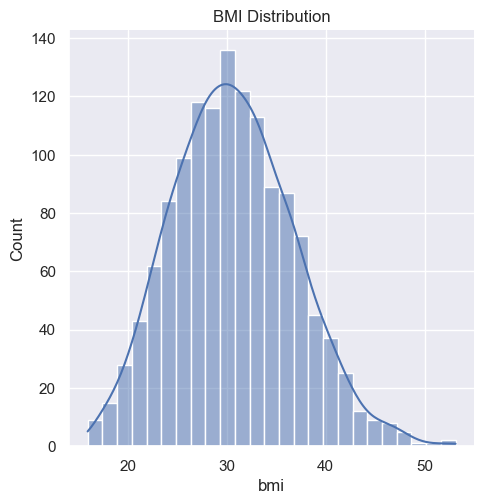

In [154]:
 # Bmi Distribution
plt.figure(figsize=(6,6))
sns.displot(insurance_dataset['bmi'],kde=True)
plt.title('BMI Distribution')
plt.show()

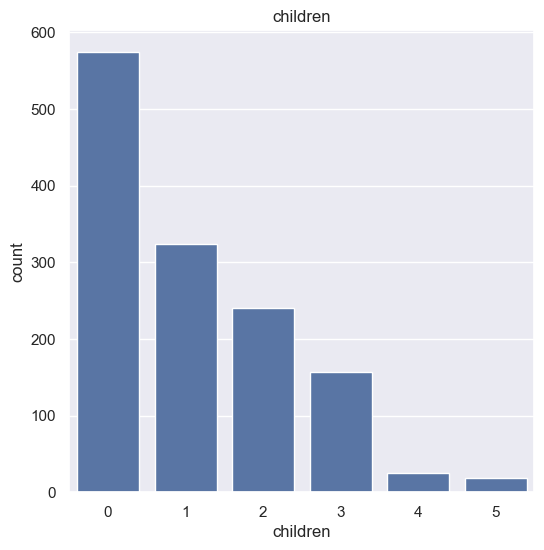

In [155]:
# children column 
plt.figure(figsize=(6,6))
sns.countplot(x='children', data=insurance_dataset)
plt.title('children')
plt.show()
              

In [156]:
insurance_dataset['children'].value_counts()


children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

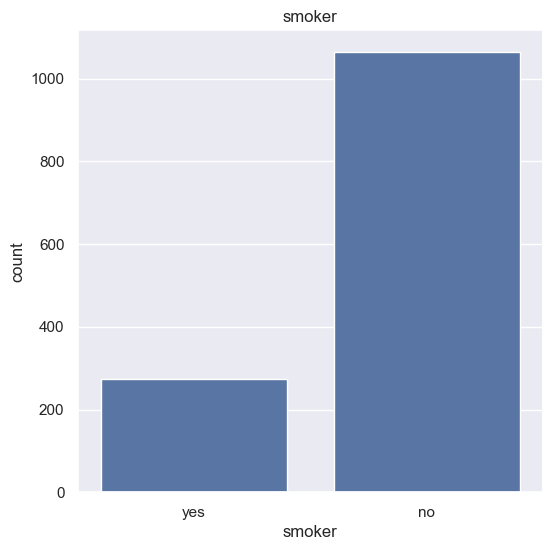

In [157]:
# smoker column 
plt.figure(figsize=(6,6))
sns.countplot(x='smoker', data=insurance_dataset)
plt.title('smoker')
plt.show()
              

In [158]:
insurance_dataset['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

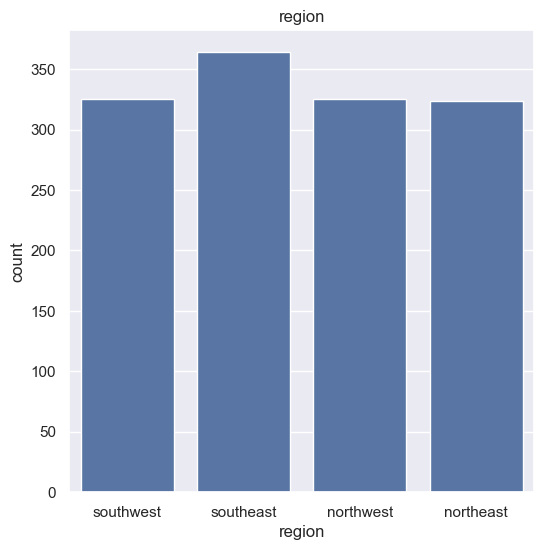

In [159]:
# region column 
plt.figure(figsize=(6,6))
sns.countplot(x='region', data=insurance_dataset)
plt.title('region')
plt.show()

In [160]:
insurance_dataset['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

<Figure size 600x600 with 0 Axes>

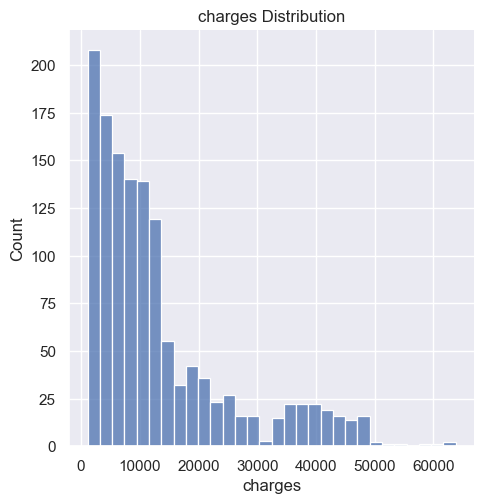

In [161]:
#Distribution of charges value 
plt.figure(figsize=(6,6))
sns.displot(insurance_dataset['charges'])
plt.title('charges Distribution')
plt.show()

## Data Pre-processing
## Encoding the categorical features


In [175]:
 # encoding sex column
insurance_dataset.replace({'sex':{'male':0, 'female':1}}, inplace=True)

 # encoding smoker column
insurance_dataset.replace({'smoker':{'yes':0, 'no':1}}, inplace=True)

 # encoding region column
insurance_dataset.replace({'region':{'southeast':0, 'southwest':1, 'northeast':2, 'northwest':3 }}, inplace=True);
 

## Splitting the Features and Target

In [176]:
X = insurance_dataset.drop(columns='charges' , axis=1)
Y = insurance_dataset['charges']

In [177]:
print(X)

      age  sex     bmi  children  smoker  region
0      19    1  27.900         0       0       1
1      18    0  33.770         1       1       0
2      28    0  33.000         3       1       0
3      33    0  22.705         0       1       3
4      32    0  28.880         0       1       3
...   ...  ...     ...       ...     ...     ...
1333   50    0  30.970         3       1       3
1334   18    1  31.920         0       1       2
1335   18    1  36.850         0       1       0
1336   21    1  25.800         0       1       1
1337   61    1  29.070         0       0       3

[1338 rows x 6 columns]


In [178]:
print(Y)

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


## Splitting the data into Training data & Testing data

In [179]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=2)

In [180]:
print(X.shape, X_train.shape,X_test.shape)

(1338, 6) (1070, 6) (268, 6)


## Model Training (LINEAR REGRESSION)

In [181]:
# Loading the Linear Regression model
regressor = LinearRegression() 

In [182]:
regressor.fit(X_train,Y_train);

 ## Model Evaluation

In [183]:
# prediction on training data 
training_data_prediction = regressor.predict(X_train)

In [184]:
# R squared value
r2_train = metrics.r2_score(Y_train,training_data_prediction)
print('R squared value : ',r2_train)

R squared value :  0.751505643411174


In [185]:
# prediction on testing data 
test_data_prediction = regressor.predict(X_test)

In [186]:
 # R squared value
r2_test = metrics.r2_score(Y_test,test_data_prediction)
print('R squared value : ',r2_test)

R squared value :  0.7447273869684077


## Building a Predictive System

In [187]:
input_data = (31,1,25.74,0,1,0)

# changing input_data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshapethe array
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
prediction = regressor.predict(input_data_reshaped)
print(prediction)

print('The insurance cost is USD ', prediction[0])

[3760.0805765]
The insurance cost is USD  3760.0805764960405


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [2]:
import pickle

with open("linear_regression_model.pkl", "wb") as file:
    pickle.dump(regressor, file)


NameError: name 'regressor' is not defined